In [4]:
import xarray as xr
import numpy as np

In [2]:
import pandas as pd

file_path = "/projects/prjs2023/chapter3/merged_base_MM_DM_fluxnet_GPP_with_FPCGPP.csv"

df = pd.read_csv(file_path)

df

,TIMESTAMP,GPP_NT_VUT_REF,source_file,date,GPP_fluxnet_monthly,site_id,lat,lon,time,GPP_base,GPP_droughtmort,GPP_monthlybackground,IGBP,GPP_base_weighted,GPP_MM_weighted,GPP_DM_weighted
0,200901,9.54930,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-01-01,296.02830,AR-SLu,-33.4648,-66.4598,2009-01-01,285.518830,262.471650,278.54617,MF,271.685398,255.468089,223.796802
1,200902,9.58507,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-02-01,268.38196,AR-SLu,-33.4648,-66.4598,2009-02-01,230.858140,229.888210,224.26028,MF,178.836003,164.984294,216.754947
2,200903,9.47598,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-03-01,293.75538,AR-SLu,-33.4648,-66.4598,2009-03-01,213.014100,237.345050,208.70354,MF,142.773372,136.638082,241.278467
3,200904,9.15312,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-04-01,274.59360,AR-SLu,-33.4648,-66.4598,2009-04-01,147.944170,187.903030,145.21759,MF,94.522959,87.378515,237.845408
4,200905,8.37331,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-05-01,259.57261,AR-SLu,-33.4648,-66.4598,2009-05-01,122.385124,139.978060,121.21308,MF,84.548539,78.978853,165.883574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16579,200908,1.22150,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-08-01,37.86650,ZM-Mon,-15.4391,23.2525,2009-08-01,0.000000,0.000000,0.00000,DBF,NaN,NaN,NaN
16580,200909,1.49847,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-09-01,44.95410,ZM-Mon,-15.4391,23.2525,2009-09-01,0.000000,0.000000,0.00000,DBF,NaN,NaN,NaN
16581,200910,1.57695,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-10-01,48.88545,ZM-Mon,-15.4391,23.2525,2009-10-01,0.000000,0.012477,0.00000,DBF,NaN,NaN,NaN
16582,200911,1.32243,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-11-01,39.67290,ZM-Mon,-15.4391,23.2525,2009-11-01,292.997680,288.632480,292.89285,DBF,NaN,NaN,NaN


In [3]:
def standardized_anomalies(data):
    climatology_mean = data.groupby('time.month').mean('time')
    climatology_std = data.groupby('time.month').std('time')
    
    # Check if climatology_std is not zero
    climatology_std_nonzero = climatology_std.where(climatology_std != 0)
    
    # Calculate standardized anomalies only where climatology_std is not zero
    stand_anomalies = xr.apply_ufunc(lambda x, m, s: (x - m) / s if s != 0 else np.nan, 
                                      data.groupby('time.month'), climatology_mean, climatology_std_nonzero,
                                      dask='allowed', vectorize=True)
    print('anomalies done')
    return stand_anomalies


In [5]:
import pandas as pd
import numpy as np

# Ensure datetime
df['time'] = pd.to_datetime(df['time'])

# Extract month
df['month'] = df['time'].dt.month

# GPP variables to standardize
gpp_cols = [
    'GPP_fluxnet_monthly',
    'GPP_base',
    'GPP_droughtmort',
    'GPP_monthlybackground',
    'GPP_base_weighted',
    'GPP_MM_weighted',
    'GPP_DM_weighted'
]

for col in gpp_cols:
    
    # Monthly climatology for each site
    clim_mean = (
        df.groupby(['site_id', 'month'])[col]
        .transform('mean')
    )
    
    clim_std = (
        df.groupby(['site_id', 'month'])[col]
        .transform('std')
    )
    
    # Avoid division by zero
    clim_std = clim_std.replace(0, np.nan)
    
    # Standardized anomaly
    df[f'{col}_std_anom'] = (df[col] - clim_mean) / clim_std

print(df.filter(regex='std_anom').head())

   GPP_fluxnet_monthly_std_anom  GPP_base_std_anom  GPP_droughtmort_std_anom  \
0                     -1.063395           0.467746                 -0.269662   
1                      1.082657          -0.520126                  0.324948   
2                      1.105999          -1.118641                 -1.153445   
3                      1.025973          -1.152980                 -0.988107   
4                      0.828925          -1.068632                 -0.866529   

   GPP_monthlybackground_std_anom  GPP_base_weighted_std_anom  \
0                        0.389732                    1.067902   
1                       -0.456115                    1.083310   
2                       -1.146854                    0.734342   
3                       -1.073898                    1.154016   
4                       -1.141534                    0.098517   

   GPP_MM_weighted_std_anom  GPP_DM_weighted_std_anom  
0                  0.366605                 -0.709764  
1               

In [6]:
df

,TIMESTAMP,GPP_NT_VUT_REF,source_file,date,GPP_fluxnet_monthly,site_id,lat,lon,time,GPP_base,...,GPP_MM_weighted,GPP_DM_weighted,month,GPP_fluxnet_monthly_std_anom,GPP_base_std_anom,GPP_droughtmort_std_anom,GPP_monthlybackground_std_anom,GPP_base_weighted_std_anom,GPP_MM_weighted_std_anom,GPP_DM_weighted_std_anom
0,200901,9.54930,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-01-01,296.02830,AR-SLu,-33.4648,-66.4598,2009-01-01,285.518830,...,255.468089,223.796802,1,-1.063395,0.467746,-0.269662,0.389732,1.067902,0.366605,-0.709764
1,200902,9.58507,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-02-01,268.38196,AR-SLu,-33.4648,-66.4598,2009-02-01,230.858140,...,164.984294,216.754947,2,1.082657,-0.520126,0.324948,-0.456115,1.083310,-0.685521,0.378450
2,200903,9.47598,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-03-01,293.75538,AR-SLu,-33.4648,-66.4598,2009-03-01,213.014100,...,136.638082,241.278467,3,1.105999,-1.118641,-1.153445,-1.146854,0.734342,-0.346066,0.151019
3,200904,9.15312,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-04-01,274.59360,AR-SLu,-33.4648,-66.4598,2009-04-01,147.944170,...,87.378515,237.845408,4,1.025973,-1.152980,-0.988107,-1.073898,1.154016,-1.147730,1.140439
4,200905,8.37331,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-05-01,259.57261,AR-SLu,-33.4648,-66.4598,2009-05-01,122.385124,...,78.978853,165.883574,5,0.828925,-1.068632,-0.866529,-1.141534,0.098517,-1.138136,0.301807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16579,200908,1.22150,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-08-01,37.86650,ZM-Mon,-15.4391,23.2525,2009-08-01,0.000000,...,NaN,NaN,8,-0.408453,-0.500000,NaN,-0.718292,NaN,NaN,NaN
16580,200909,1.49847,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-09-01,44.95410,ZM-Mon,-15.4391,23.2525,2009-09-01,0.000000,...,NaN,NaN,9,-0.307374,NaN,NaN,NaN,NaN,NaN,NaN
16581,200910,1.57695,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-10-01,48.88545,ZM-Mon,-15.4391,23.2525,2009-10-01,0.000000,...,NaN,NaN,10,-0.738090,-0.664411,-0.657598,-0.664438,NaN,NaN,NaN
16582,200911,1.32243,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-11-01,39.67290,ZM-Mon,-15.4391,23.2525,2009-11-01,292.997680,...,NaN,NaN,11,-1.364066,0.899850,0.932606,0.901030,NaN,NaN,NaN


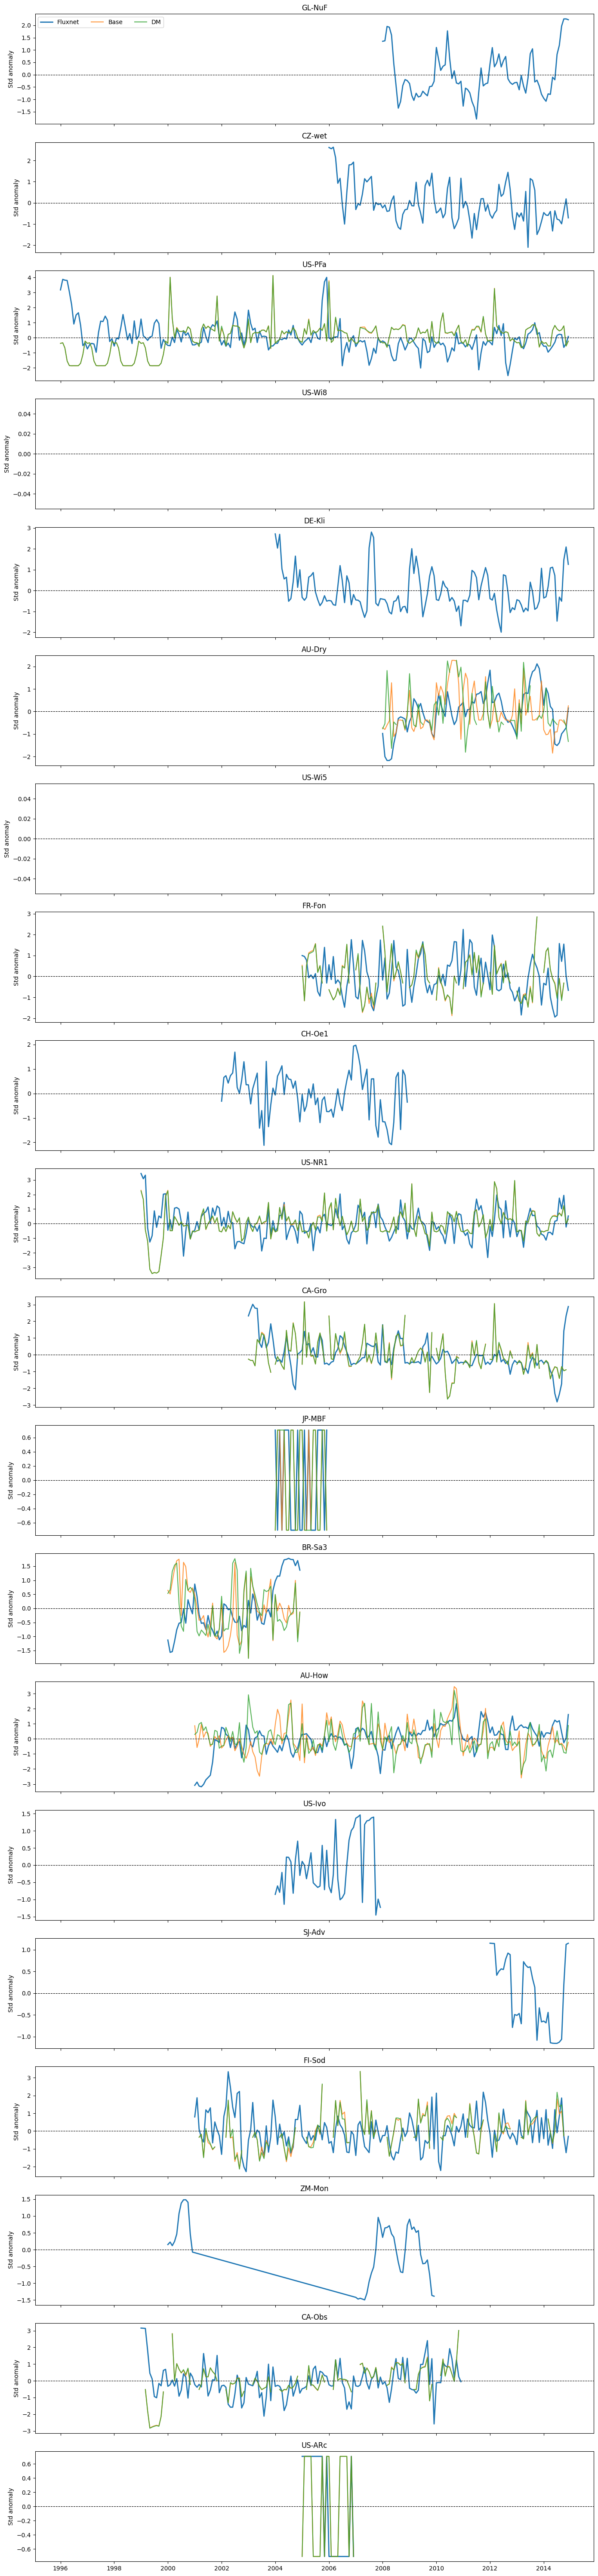

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# choose a few sites
sites = df['site_id'].drop_duplicates().sample(20, random_state=41)

fig, axes = plt.subplots(len(sites), 1,
                         figsize=(14, 3*len(sites)),
                         sharex=True)

if len(sites) == 1:
    axes = [axes]

for ax, site in zip(axes, sites):

    site_df = (
        df[df['site_id'] == site]
        .sort_values('time')
    )

    ax.plot(
        site_df['time'],
        site_df['GPP_fluxnet_monthly_std_anom'],
        label='Fluxnet',
        lw=2
    )

    ax.plot(
        site_df['time'],
        site_df['GPP_base_weighted_std_anom'],
        label='Base',
        alpha=0.8
    )

    ax.plot(
        site_df['time'],
        site_df['GPP_DM_weighted_std_anom'],
        label='DM',
        alpha=0.8
    )

    ax.axhline(0, color='k', ls='--', lw=0.8)
    ax.set_title(site)
    ax.set_ylabel('Std anomaly')

axes[0].legend(ncol=3)
plt.tight_layout()
plt.show()